# ML-testbed 10 — learn a world that can roll forward

A world model should predict a sequence, not just a final label. Train a residual network to advance the machine state one step, then repeatedly feed its predictions back into itself. Small one-step errors may compound into a poor future.

## How to use this lesson
Run from the top with **Python (Factor AI)** or the environment in `docs/WORLD_MODEL_COURSE.md`. Each notebook runs independently; later notebooks reuse the small `ml_testbed` package. No API calls or model downloads occur. Training uses the CPU to make the default run portable.

**Skills:** state transitions, teacher forcing, autoregressive rollout, train-only scaling, extrapolation and baselines

**Evidence contract:** all saved results are exposed synthetic development evidence. Train, tuning, calibration and evaluation draws have separate seeds where used. Re-running and tuning on these evaluation draws makes them development data; they are not a secret final test. Never split frames from one shot across train and evaluation.

**Scope:** a dimensionless, pre-stagnation Z-inspired teaching model. It is not a calibrated digital twin of Sandia's Z machine. The thermal and perturbation variables are proxies; they do not identify phase, ETI, MRTI, or fusion performance.

In [1]:
from pathlib import Path
import sys, json, copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from dataclasses import asdict, replace
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ml_testbed').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the ML-testbed repo, with ml_testbed/ beside notebooks/.')
sys.path.insert(0, str(ROOT))
from ml_testbed.world import *
from ml_testbed.learning import seed_all, fit, save_run, grid_posterior, weighted_interval, entropy
seed_all(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
DEVICE = torch.device('cpu')
print('PyTorch', torch.__version__, '| CPU | dimensionless teaching world v1')

PyTorch 2.14.0 | CPU | dimensionless teaching world v1


## 1. Define what this world model gets to see
This is supervised system identification using **full simulator states** and known machine parameters during training. It is easier than inferring hidden states from diagnostics. Lesson 11 addresses observation encoding; the capstone links inference to future predictions. The step length is fixed by this notebook's time grid and is part of the model contract.

In [2]:
cfg=replace(MachineConfig(),samples=32)
train_theta=draw_parameters(96,10001); dev_theta=draw_parameters(24,10101)
eval_theta=draw_parameters(24,10201); shift_theta=draw_parameters(24,10301,shifted=True)
with torch.no_grad():
    t,train_s=simulate(train_theta,cfg); _,dev_s=simulate(dev_theta,cfg)
    _,eval_s=simulate(eval_theta,cfg); _,shift_s=simulate(shift_theta,cfg)
center=train_s.mean((0,1)); scale=train_s.std((0,1)).clamp_min(.005)
pcenter=train_theta.mean(0); pscale=train_theta.std(0).clamp_min(.01)
def transitions(s,p):
    state=(s-center)/scale
    controls=((p-pcenter)/pscale)[:,None,:].expand(-1,s.shape[1]-1,-1)
    features=torch.cat([state[:,:-1],controls],-1).reshape(-1,10)
    delta=(state[:,1:]-state[:,:-1]).reshape(-1,6)
    return features,delta
x,y=transitions(train_s,train_theta); xv,yv=transitions(dev_s,dev_theta)
print('Training transitions:',x.shape,'independent training shots:',len(train_theta))

Training transitions: torch.Size([2976, 10]) independent training shots: 96


## 2. Learn a residual update
The network predicts a change in normalized state. The identity path already preserves the current state. This tends to be easier to learn than predicting the entire next state from scratch. A residual architecture alone does not enforce energy conservation or positive radius.

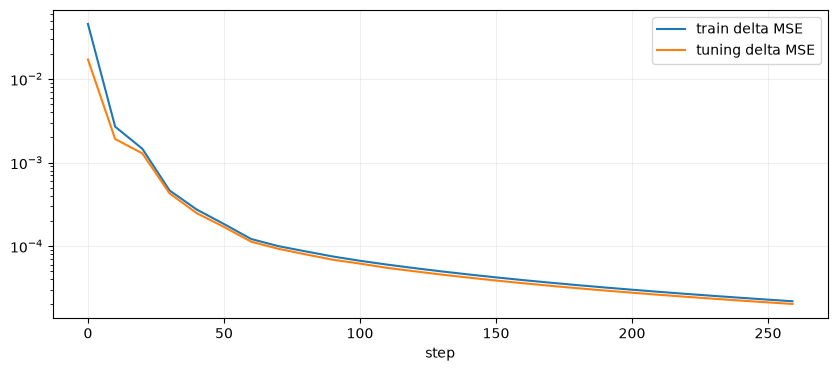

In [3]:
seed_all(10)
net=nn.Sequential(nn.Linear(10,64),nn.Tanh(),nn.Linear(64,64),nn.Tanh(),nn.Linear(64,6))
h=fit(net,x,y,xv,yv,steps=260,lr=.003)
plt.semilogy(h[:,0],h[:,1],label='train delta MSE'); plt.semilogy(h[:,0],h[:,2],label='tuning delta MSE'); plt.legend(); plt.xlabel('step'); plt.show()
@torch.no_grad()
def rollout(model,initial,parameters,steps):
    current=(initial-center)/scale; path=[initial]
    p=(parameters-pcenter)/pscale
    for _ in range(steps-1):
        current=current+model(torch.cat([current,p],1))
        path.append(current*scale+center)
    return torch.stack(path,1)
pred=rollout(net,eval_s[:,0],eval_theta,len(t)); shifted_pred=rollout(net,shift_s[:,0],shift_theta,len(t))

### Visual lab — Teacher forcing versus free rollout

During one-step training, every prediction starts from a true simulated state. During rollout, the next input is the model's own prediction. Errors can therefore feed back and accumulate.

**Predict:** can low one-step loss coexist with a poor long rollout? Compare this diagram with the horizon-error plot below.

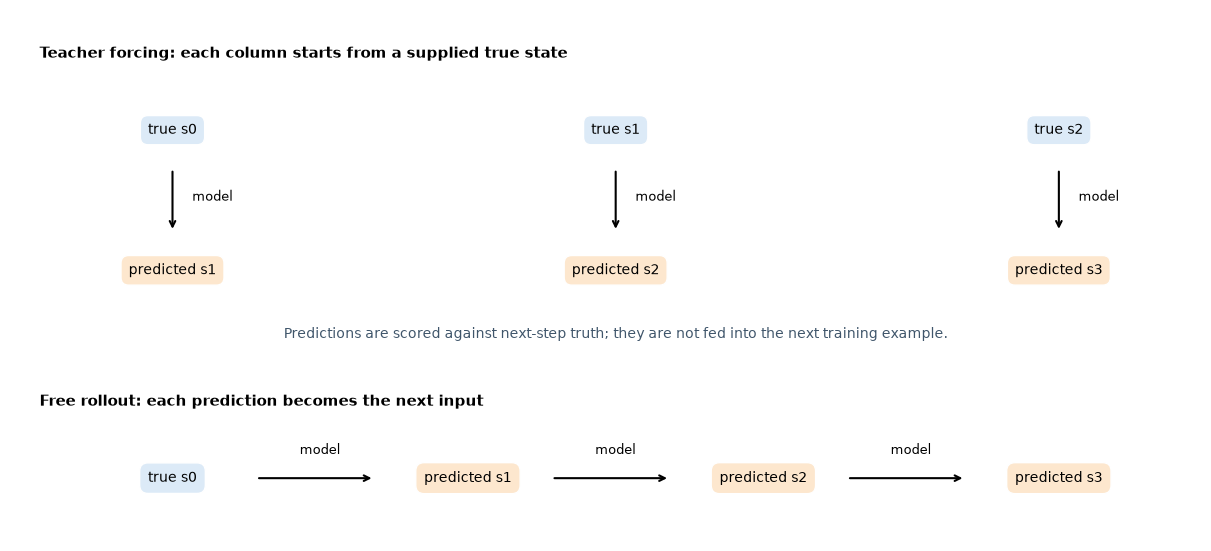

In [4]:
v_fig,v_ax=plt.subplots(figsize=(12,5.4),layout='constrained'); v_ax.axis('off')
v_ax.text(-1.35,3.4,'Teacher forcing: each column starts from a supplied true state',weight='bold',fontsize=11)
for v_i,v_x in enumerate([0,4.5,9]):
    v_ax.text(v_x,2.65,f'true s{v_i}',ha='center',va='center',bbox=dict(boxstyle='round,pad=.55',fc='#dceaf7',ec='white'))
    v_ax.text(v_x,1.2,f'predicted s{v_i+1}',ha='center',va='center',bbox=dict(boxstyle='round,pad=.55',fc='#fde7ce',ec='white'))
    v_ax.annotate('',xy=(v_x,1.6),xytext=(v_x,2.25),arrowprops=dict(arrowstyle='->',lw=1.5))
    v_ax.text(v_x+.2,1.92,'model',fontsize=9)
v_ax.text(4.5,.5,'Predictions are scored against next-step truth; they are not fed into the next training example.',ha='center',fontsize=10,color='#40566b')
v_ax.text(-1.35,-.2,'Free rollout: each prediction becomes the next input',weight='bold',fontsize=11)
for v_i in range(4):
    v_label='true s0' if v_i==0 else f'predicted s{v_i}'
    v_ax.text(v_i*3,-.95,v_label,ha='center',va='center',bbox=dict(boxstyle='round,pad=.6',fc='#dceaf7' if v_i==0 else '#fde7ce',ec='white'))
    if v_i<3:
        v_ax.annotate('',xy=(v_i*3+2.05,-.95),xytext=(v_i*3+.85,-.95),arrowprops=dict(arrowstyle='->',lw=1.5))
        v_ax.text(v_i*3+1.5,-.7,'model',ha='center',fontsize=9)
v_ax.set(xlim=(-1.65,10.45),ylim=(-1.6,3.9)); plt.show()

## 3. Compare free rollout to useful baselines
Persistence predicts no change. Euler uses the generating RHS with a cheaper first-order solver, so it has privileged equation knowledge. RK4 is our reference. A learned model is not automatically useful if a cheap known-equation solver is better; report that result.

In [5]:
@torch.no_grad()
def euler(initial,parameters):
    state=initial.clone(); path=[state]; dt=t[1]-t[0]
    for _ in range(len(t)-1):
        state=state+dt*rhs(state,parameters,cfg); path.append(state)
    return torch.stack(path,1)
euler_pred=euler(eval_s[:,0],eval_theta)
persist=eval_s[:,0:1].expand_as(eval_s)
def normalized_rmse(a,b): return float(torch.mean(((a-b)/scale)**2).sqrt())
metrics={'learned_matched':normalized_rmse(pred,eval_s),'Euler_matched':normalized_rmse(euler_pred,eval_s),
         'persistence_matched':normalized_rmse(persist,eval_s),'learned_shifted':normalized_rmse(shifted_pred,shift_s)}
print(metrics)

{'learned_matched': 0.2266288548707962, 'Euler_matched': 0.057060204446315765, 'persistence_matched': 1.5134094953536987, 'learned_shifted': 1.0369161367416382}


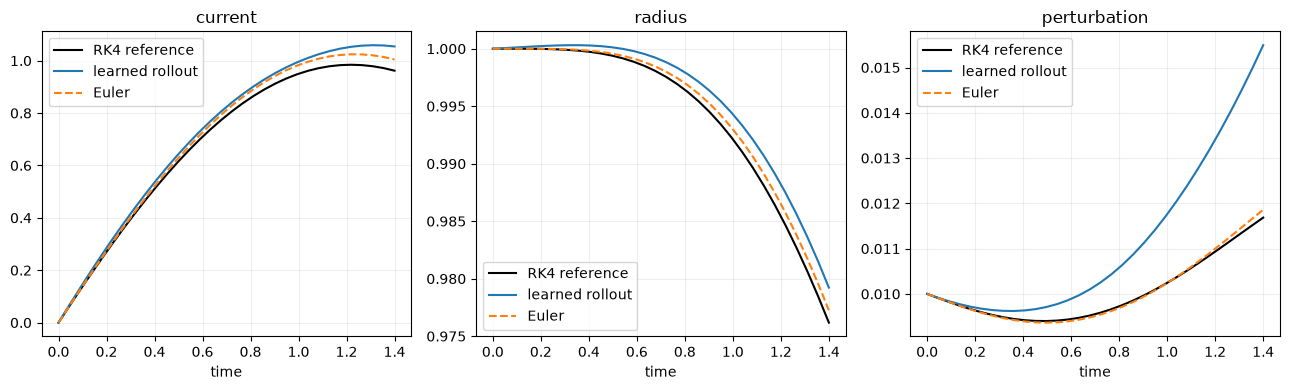

In [6]:
fig,axes=plt.subplots(1,3,figsize=(13,4))
for ax,j in zip(axes,[1,2,5]):
    ax.plot(t,eval_s[0,:,j],'k',label='RK4 reference'); ax.plot(t,pred[0,:,j],label='learned rollout'); ax.plot(t,euler_pred[0,:,j],'--',label='Euler')
    ax.set(title=STATE_NAMES[j],xlabel='time'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Measure accumulation and domain failures
One-step evaluation gives the model true states at every step. Free rollout uses its own history. Plot error versus prediction horizon. Record unphysical radius predictions instead of clipping them out of the score.

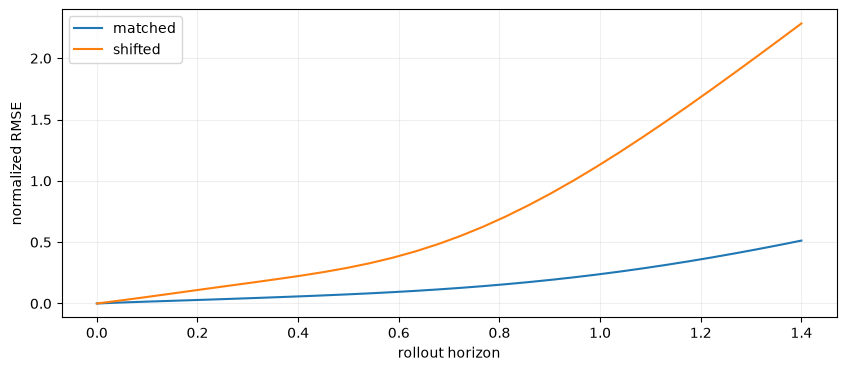

one-step MSE: 4.5607415813719854e-05 invalid radius fraction: 0.0
/Users/operator/Desktop/Factor/runs/world-model/10-c77047c145


In [7]:
with torch.no_grad():
    xe,ye=transitions(eval_s,eval_theta); one_step=float(nn.functional.mse_loss(net(xe),ye))
horizon=((pred-eval_s)/scale).square().mean((0,2)).sqrt()
shift_horizon=((shifted_pred-shift_s)/scale).square().mean((0,2)).sqrt()
plt.plot(t,horizon,label='matched'); plt.plot(t,shift_horizon,label='shifted'); plt.xlabel('rollout horizon'); plt.ylabel('normalized RMSE'); plt.legend(); plt.show()
metrics['one_step_delta_MSE']=one_step
metrics['invalid_radius_fraction']=float(((shifted_pred[:,:,2]<=0)|(shifted_pred[:,:,2]>1.05)).float().mean())
print('one-step MSE:',one_step,'invalid radius fraction:',metrics['invalid_radius_fraction'])
run=save_run(ROOT,'10',metrics,{'dt':float(t[1]-t[0]),'steps':260,'state_information':'full simulator state'})
torch.save({'state_dict':net.state_dict(),'state_center':center,'state_scale':scale,'parameter_center':pcenter,'parameter_scale':pscale,'config':asdict(cfg)},run/'world_model.pt')
print(run)

### Visual lab — Which shots drift as the forecast gets longer?

Color is root-mean-square state error after dividing each state by its training-set scale. Every row is a separate held-out shot, and the two panels use the same color scale.

**Notice:** the mean horizon curve can hide a subset of difficult trajectories. The shifted panel changes the parameter distribution rather than supplying more training data.

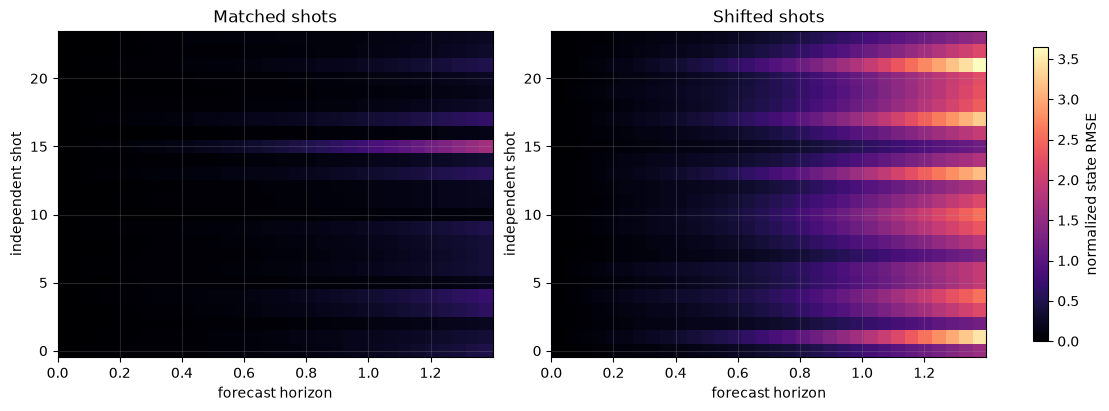

In [8]:
v_matched_error=((pred-eval_s)/scale).square().mean(-1).sqrt().numpy()
v_shift_error=((shifted_pred-shift_s)/scale).square().mean(-1).sqrt().numpy()
v_max=max(v_matched_error.max(),v_shift_error.max())
v_fig,v_axes=plt.subplots(1,2,figsize=(11,4),layout='constrained')
for v_ax,v_image,v_title in zip(v_axes,[v_matched_error,v_shift_error],['Matched shots','Shifted shots']):
    v_im=v_ax.imshow(v_image,origin='lower',aspect='auto',extent=[0,float(t[-1]),-.5,len(v_image)-.5],cmap='magma',vmin=0,vmax=v_max)
    v_ax.set(title=v_title,xlabel='forecast horizon',ylabel='independent shot')
v_fig.colorbar(v_im,ax=v_axes,label='normalized state RMSE',shrink=.9); plt.show()

## Your next experiments

Write a prediction, change one thing, and save both successes and failures.

1. Train on five-step rollouts and compare long-horizon error at equal compute budget.
2. Add an energy-balance penalty and check whether it improves both matched and shifted predictions.
3. Introduce a time-varying control, then pass it to the transition model explicitly rather than hiding it in the state.